<a href="https://colab.research.google.com/github/souhirbenamor/EPF/blob/main/Evaluation_Metrics_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade tensorflow==2.12.1

In [ ]:
!pip install gitpython

In [ ]:
import os
from git.repo.base import Repo
Repo.clone_from("https://github.com/jeslago/epftoolbox", "epftoolbox")

<git.repo.base.Repo '/content/epftoolbox/.git'>

In [ ]:
cd epftoolbox

/content/epftoolbox


In [ ]:
from epftoolbox.evaluation import MAE, RMSE, MAPE, sMAPE, MASE, rMAE
import pandas as pd
from epftoolbox.evaluation import naive_forecast

In [ ]:
# Reading the forecast data
forecast = pd.read_excel('/content/Final_Forcasting_results_single_stat_model.xlsx')
forecast.reset_index(inplace=True)
forecast["Date"] = pd.to_datetime(forecast["Date"])
forecast = forecast.set_index('Date')

# Extracting the real price
real_price = forecast.iloc[:, 1]

# Reading the full sample data for the naive forecast calculation
df = pd.read_csv('/content/EPF_data_FUND25.csv')
df.reset_index(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Consider the train sample for the naive forecast calculation
y_train = df[:-17640]
real_price_insample = y_train.iloc[:, 1]
real_price_insample = pd.DataFrame(real_price_insample)

# Calculating the naive forecast
naive_fc = naive_forecast(p_real=real_price_insample, m='W', n_prices_day=24)

# Prepare a DataFrame to store the evaluation metrics results
metrics_list = []

# Calculate metrics for each forecasted column
for col in forecast.columns[2:]:
    fc_model = forecast[col]
    metrics = {
        'Model': col,
        'MAE': MAE(p_pred=fc_model, p_real=real_price),
        'RMSE': RMSE(p_pred=fc_model, p_real=real_price),
        'MAPE': MAPE(p_pred=fc_model, p_real=real_price),
        'sMAPE': sMAPE(p_pred=fc_model, p_real=real_price),
        'MASE': MASE(p_pred=fc_model, p_real=real_price, p_real_in=real_price_insample, m='W'),
        'rMAE': rMAE(p_pred=fc_model, p_real=real_price)
    }
    metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list)

# Set the 'Model' column as the index
metrics_df.set_index('Model', inplace=True)

# Convert the DataFrame to a LaTeX table
latex_table = metrics_df.to_latex(index=True, float_format="%.4f")

# Display the LaTeX table
print(latex_table)

\begin{tabular}{lrrrrrr}
\toprule
 & MAE & RMSE & MAPE & sMAPE & MASE & rMAE \\
Model &  &  &  &  &  &  \\
\midrule
LSTM & 17.3936 & 27.2766 & inf & 0.3285 & 0.5131 & 0.6300 \\
LARX & 28.8896 & 38.7004 & inf & 0.5504 & 0.8523 & 1.0464 \\
RF & 21.5407 & 33.3805 & inf & 0.3914 & 0.6355 & 0.7802 \\
\bottomrule
\end{tabular}



/content/epftoolbox/epftoolbox/evaluation/_mape.py:118: RuntimeWarning: divide by zero encountered in divide
  mape = np.abs(p_real - p_pred) / np.abs(p_real)
/content/epftoolbox/epftoolbox/evaluation/_mape.py:118: RuntimeWarning: divide by zero encountered in divide
  mape = np.abs(p_real - p_pred) / np.abs(p_real)
/content/epftoolbox/epftoolbox/evaluation/_mape.py:118: RuntimeWarning: divide by zero encountered in divide
  mape = np.abs(p_real - p_pred) / np.abs(p_real)


In [ ]:
from epftoolbox.evaluation import DM, plot_multivariate_DM_test
from epftoolbox.data import read_data
import pandas as pd

In [ ]:
 # Generating forecasts of multiple models
 # Download available forecast of the NP market available in the library repository
 # These forecasts accompany the original paper
forecasts = pd.read_excel('/content/Final_Forcasting_results_single_stat_model.xlsx', index_col=0)
forecasts

,Real Price,LSTM,LARX,RF
Date,,,,
2023-01-01 00:00:00,-1.07,13.122683,50.623460,8.788515
2023-01-01 01:00:00,-1.47,-7.767603,46.528870,8.383049
2023-01-01 02:00:00,-5.08,-19.974483,44.832425,8.524964
2023-01-01 03:00:00,-4.49,-16.868441,45.596559,8.589269
2023-01-01 04:00:00,-5.40,-17.889210,44.920089,8.571056
...,...,...,...,...
2024-12-31 19:00:00,35.56,43.898834,37.910193,23.025288
2024-12-31 20:00:00,15.70,37.992340,28.274479,7.161620
2024-12-31 21:00:00,9.06,33.392933,19.583065,5.373641


In [ ]:
# Deleting the real price field as it the actual real price and not a forecast
del forecasts['Real Price']

forecasts

,LSTM,LARX,RF
Date,,,
2023-01-01 00:00:00,13.122683,50.623460,8.788515
2023-01-01 01:00:00,-7.767603,46.528870,8.383049
2023-01-01 02:00:00,-19.974483,44.832425,8.524964
2023-01-01 03:00:00,-16.868441,45.596559,8.589269
2023-01-01 04:00:00,-17.889210,44.920089,8.571056
...,...,...,...
2024-12-31 19:00:00,43.898834,37.910193,23.025288
2024-12-31 20:00:00,37.992340,28.274479,7.161620
2024-12-31 21:00:00,33.392933,19.583065,5.373641


In [ ]:
# Transforming indices to datetime format
forecasts.index = pd.to_datetime(forecasts.index)
forecasts

,LSTM,LARX,RF
Date,,,
2023-01-01 00:00:00,13.122683,50.623460,8.788515
2023-01-01 01:00:00,-7.767603,46.528870,8.383049
2023-01-01 02:00:00,-19.974483,44.832425,8.524964
2023-01-01 03:00:00,-16.868441,45.596559,8.589269
2023-01-01 04:00:00,-17.889210,44.920089,8.571056
...,...,...,...
2024-12-31 19:00:00,43.898834,37.910193,23.025288
2024-12-31 20:00:00,37.992340,28.274479,7.161620
2024-12-31 21:00:00,33.392933,19.583065,5.373641


In [ ]:
#Extracting the real prices from the market
df = pd.read_csv('/content/EPF_data_FUND25.csv',index_col=0)
df.index = pd.to_datetime(df.index)
df

,Price,Demand Day-ahead DE,Wind and PV Day ahead (MWh/h),Gas,Coal,CO2
Date,,,,,,
2019-01-01 00:00:00,10.07,41662.750000,25668.75,21.980,75.44,24.73
2019-01-01 01:00:00,-4.08,40553.000000,27384.00,21.980,75.44,24.73
2019-01-01 02:00:00,-9.91,40261.250000,29010.25,21.980,75.44,24.73
2019-01-01 03:00:00,-7.41,40603.250000,30359.25,21.980,75.44,24.73
2019-01-01 04:00:00,-12.55,40904.250000,31409.25,21.980,75.44,24.73
...,...,...,...,...,...,...
2024-12-31 20:00:00,15.70,52497.653679,42510.00,50.525,110.06,71.14
2024-12-31 21:00:00,9.06,49201.667324,42708.75,50.525,110.06,71.14
2024-12-31 22:00:00,0.52,47257.128235,43088.00,50.525,110.06,71.14


In [ ]:
y_test = df[-17544:]
real_price = y_test.loc[:, ['Price']]

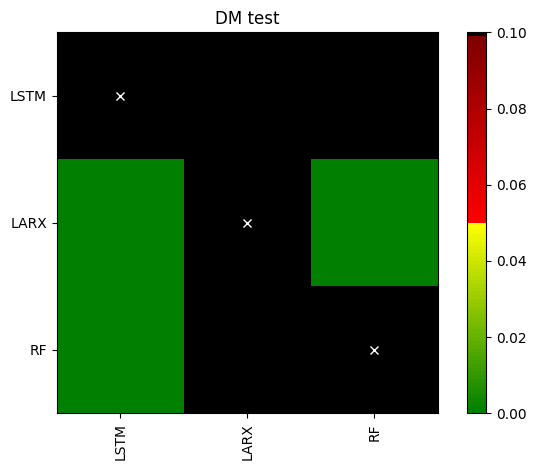

In [ ]:
# Generating a plot to compare the models using the multivariate DM test
plt=plot_multivariate_DM_test(real_price=real_price, forecasts=forecasts)